# Imputation Evaluation for Station 1

Three imputation methods — Mean, Median, and Linear Interpolation


In [18]:
# Imports & Load Data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
df = pd.read_csv("Station1_cleaned_data.csv")
df.rename(columns={'Unnamed: 0': 'Timestamp'}, inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)


In [19]:
# Imputation & Evaluation Function 
def evaluate_column(col):
    print(f"\n Evaluating '{col}'")

    if df[col].isnull().sum() == 0:
        print(f" Skipped — no missing values in '{col}'")
        return

    clean = df[df[col].notnull()].copy()
    if len(clean) < 50:
        print(f"Skipped — not enough valid data in '{col}'")
        return
    # Here I am simulating missingness (remove 10%)
    np.random.seed(42)
    sample_idx = clean.sample(frac=0.1).index
    true_vals = clean.loc[sample_idx, col]
    test_data = clean.copy()
    test_data.loc[sample_idx, col] = np.nan

    try:
        test_data[f'{col}_mean'] = test_data[col].fillna(test_data[col].mean())
        test_data[f'{col}_median'] = test_data[col].fillna(test_data[col].median())
        test_data[f'{col}_linear'] = test_data[col].interpolate(method='linear')
    except Exception as e:
        print(f"Error while imputing '{col}': {e}")
        return
    def compare(imputed_col, method_name):
        pred = test_data.loc[sample_idx, imputed_col]
        mse = mean_squared_error(true_vals, pred)
        mae = mean_absolute_error(true_vals, pred)
        print(f"{method_name:>7} → MSE: {mse:.4f}, MAE: {mae:.4f}")

    compare(f'{col}_mean', 'Mean')
    compare(f'{col}_median', 'Median')
    compare(f'{col}_linear', 'Linear')

    test_data.to_csv(f"Station1_{col}_imputed_eval.csv")
    print(f"Saved imputed file: Station1_{col}_imputed_eval.csv")


In [20]:

for col in df.columns:
    if col.lower() != 'flag':
        evaluate_column(col)


 Evaluating 'SWC_5'
   Mean → MSE: 0.0027, MAE: 0.0448
 Median → MSE: 0.0027, MAE: 0.0446
 Linear → MSE: 0.0000, MAE: 0.0006
Saved imputed file: Station1_SWC_5_imputed_eval.csv

 Evaluating 'SWC_10'
   Mean → MSE: 0.0016, MAE: 0.0350
 Median → MSE: 0.0016, MAE: 0.0350
 Linear → MSE: 0.0000, MAE: 0.0004
Saved imputed file: Station1_SWC_10_imputed_eval.csv

 Evaluating 'SWC_20'
   Mean → MSE: 0.0011, MAE: 0.0296
 Median → MSE: 0.0011, MAE: 0.0296
 Linear → MSE: 0.0000, MAE: 0.0003
Saved imputed file: Station1_SWC_20_imputed_eval.csv

 Evaluating 'SWC_50'
   Mean → MSE: 0.0012, MAE: 0.0314
 Median → MSE: 0.0013, MAE: 0.0310
 Linear → MSE: 0.0000, MAE: 0.0001
Saved imputed file: Station1_SWC_50_imputed_eval.csv

 Evaluating 'T_5'
   Mean → MSE: 90.9207, MAE: 7.9569
 Median → MSE: 90.9200, MAE: 7.9569
 Linear → MSE: 0.0856, MAE: 0.1777
Saved imputed file: Station1_T_5_imputed_eval.csv

 Evaluating 'T_10'
   Mean → MSE: 79.9103, MAE: 7.5768
 Median → MSE: 79.9257, MAE: 7.5763
 Linear → MSE:

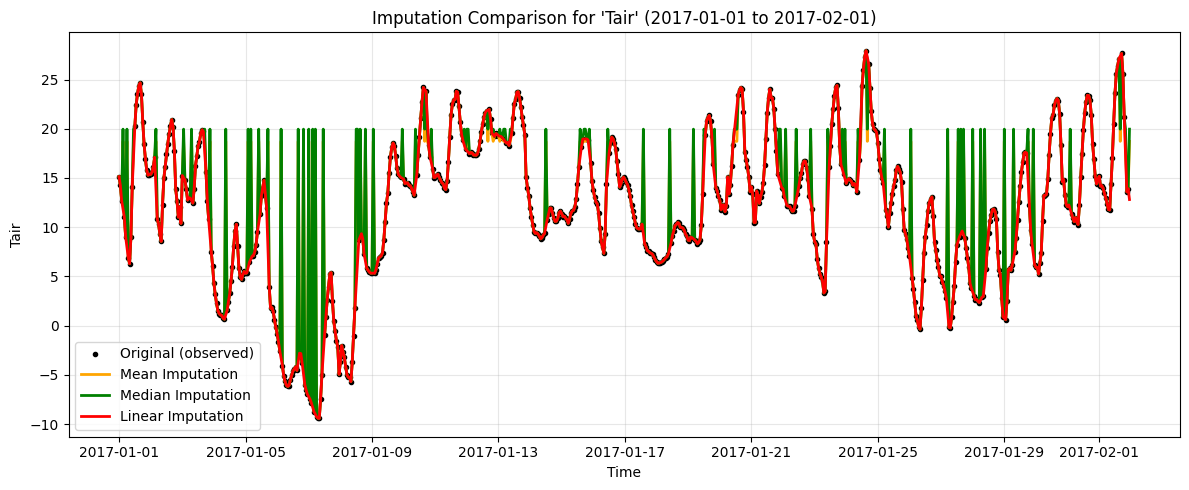

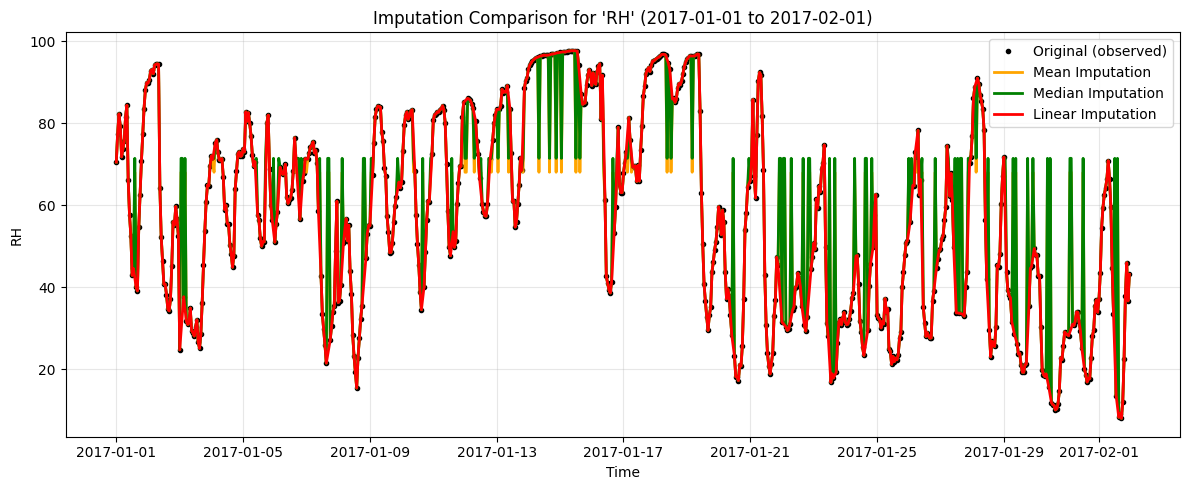

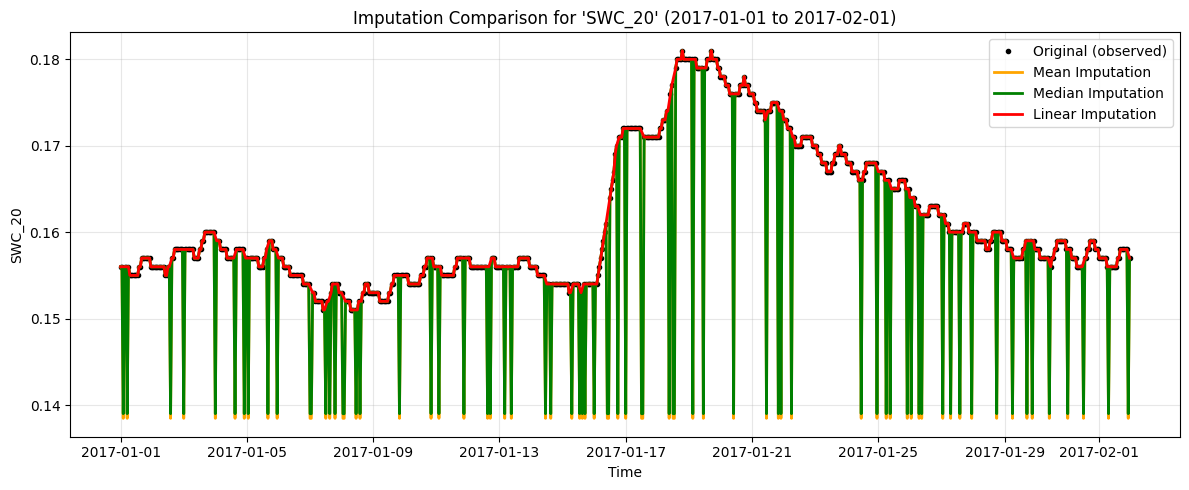

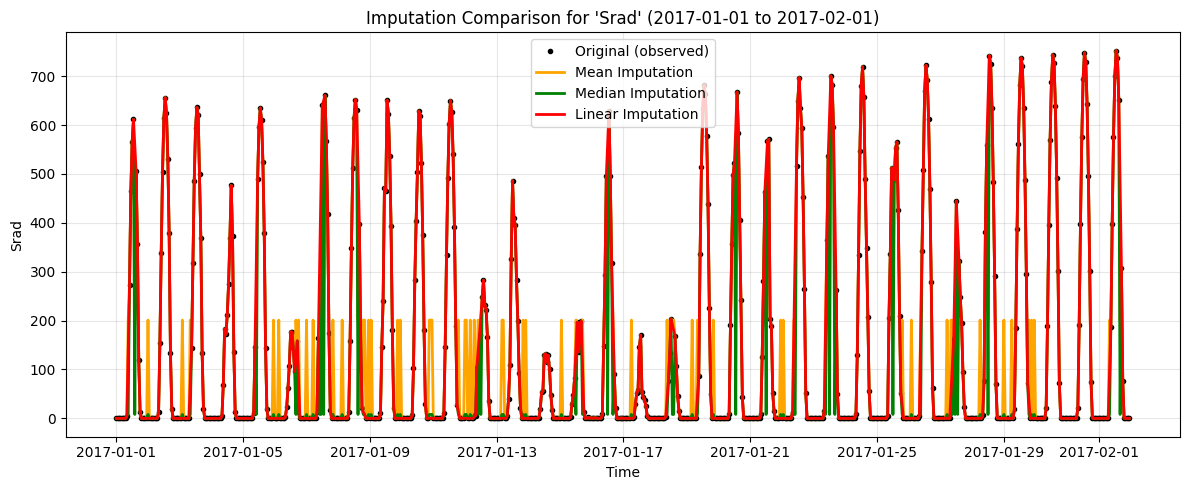

In [21]:
# Visualize Imputation Comparson 
# Plot comparison for selected columns
columns_to_plot = ['Tair', 'RH', 'SWC_20', 'Srad']

start_date = "2017-01-01"
end_date = "2017-02-01"

for col in columns_to_plot:
    file = f"Station1_{col}_imputed_eval.csv"
    try:
        data = pd.read_csv(file)
        data['Timestamp'] = pd.to_datetime(data['Timestamp'])
        data.set_index('Timestamp', inplace=True)
        plot_data = data.loc[start_date:end_date]

        plt.figure(figsize=(12, 5))

        observed = plot_data[col].notnull()
        plt.plot(plot_data.index[observed], plot_data[col][observed], 
                 label='Original (observed)', color='black', marker='o', linestyle='None', markersize=3)

        plt.plot(plot_data[f'{col}_mean'], label='Mean Imputation', color='orange', linewidth=2)
        plt.plot(plot_data[f'{col}_median'], label='Median Imputation', color='green', linewidth=2)
        plt.plot(plot_data[f'{col}_linear'], label='Linear Imputation', color='red', linewidth=2)

        plt.title(f"Imputation Comparison for '{col}' ({start_date} to {end_date})")
        plt.xlabel('Time')
        plt.ylabel(col)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️ Could not plot '{col}': {e}")


## Summary

- Linear Interpolation outperformed Mean and Median** across all four tested variables (`Tair`, `RH`, `SWC_20`, `Srad`) in terms of both the graphs and metrics (MSE, MAE).
- Mean and Median imputation**  had constant values that ignore temporal variation, often resulting in unrealistic flat lines. Linear interpolation used surrounding timestamps to generate smoother, time-aware estimates — making it more accurate for environmental time-series data like temperature, radiation, or soil moisture..
- Therefore, for small to moderate gaps in time-series environmental data, linear interpolation seems to be the preferred imputation method**.
